In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

## Task 1

### Scenario A

Type of bias : response bias

Explanation : App reviews typically reflect the "vocal minority"—users with either extremely positive or extremely negative experiences—while the silent majority of average users remain unrepresented. By ignoring this, the team risks overestimating satisfaction and making a dangerous decision to cut support, which may be the only thing preventing the "silent" users from leaving.

Concrete Fix: Implement in-app NPS (Net Promoter Score) surveys triggered at random intervals or after specific neutral tasks to capture feedback from a broader, more representative cross-section of the active user base.

### Scenario B

Type of Bias: Survivorship Bias.

Explanation: The study only looks at startups that are "still operating," completely ignoring the thousands that pivoted and failed anyway. This distorts the conclusion because it’s possible that failing startups pivoted just as often as successful ones, meaning pivoting might be a symptom of struggle rather than a cause of success.

Concrete Fix: Expand the dataset to include a control group of failed startups from the same 10-year period to see if the frequency of pivoting significantly differs between successes and failures.

### Scenario C

Type of Bias: Self-Selection Bias (and potentially Social Desirability Bias).

Explanation: People who are health-conscious are much more likely to take the time to fill out a health survey, while those with poor habits may ignore it, leading to an inflated 5-hour average. Additionally, "self-reported" health often suffers from users over-reporting "good" behaviors to align with social norms.

Concrete Fix: Use stratified random sampling to target specific demographics and offer incentives to non-respondents to increase the response rate, or supplement the survey with objective data like step-count metadata.

### Scenario D

Type of Bias: Selection Bias

Explanation: The data is heavily skewed toward high-cost-of-living urban tech hubs, which do not reflect the economic reality of a small town. Using this data to set salary bands will likely result in the small-town company setting over-market wages that are disconnected from their local labor market competition and cost of living.

Concrete Fix: Use Geographic Salary Differentials or filter the benchmarking data to only include "Tier 3" cities or companies of a similar size and location to ensure an "apples-to-apples" comparison.

## Task 2

--- True Population Parameters (Ground Truth) ---
mean_age: 40.02
mean_income: 80122.36
mean_satisfaction: 5.60
region_proportions:
  - Urban: 59.93%
  - Suburban: 25.07%
  - Rural: 15.00%


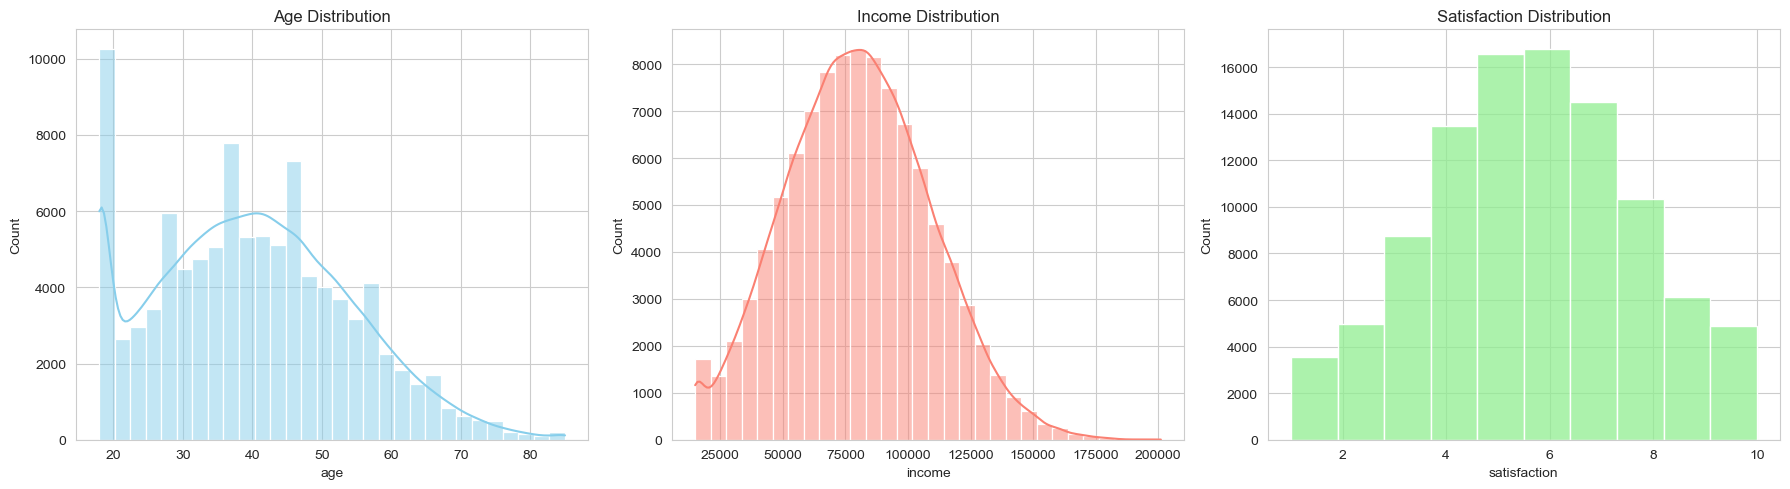

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)
n_population = 100000

# 1. Generate Age: Clipped Normal Distribution
# Center at 40, SD of 15, range [18, 85]
age = np.random.normal(loc=40, scale=15, size=n_population)
age = np.clip(age, 18, 85).astype(int)

# 2. Generate Income: Correlated with Age
# Base income + (1500 * age) + random noise
income_noise = np.random.normal(0, 20000, size=n_population)
income = 20000 + (1500 * age) + income_noise
income = np.clip(income, 15000, 250000)

# 3. Generate Satisfaction: 1-10 Scale
# Higher income slightly increases satisfaction, but with high noise
# We normalize income to a 0-1 scale to influence satisfaction
sat_noise = np.random.normal(0, 2, size=n_population)
satisfaction = 4 + (income / 50000) + sat_noise
satisfaction = np.clip(satisfaction, 1, 10).round(1)

# 4. Generate Region: Categorical
regions = ['Urban', 'Suburban', 'Rural']
region_probs = [0.60, 0.25, 0.15]
region = np.random.choice(regions, size=n_population, p=region_probs)

# Create DataFrame
pop_df = pd.DataFrame({
    'age': age,
    'income': income,
    'satisfaction': satisfaction,
    'region': region
})

# --- Compute True Population Parameters ---
true_parameters = {
    'mean_age': pop_df['age'].mean(),
    'mean_income': pop_df['income'].mean(),
    'mean_satisfaction': pop_df['satisfaction'].mean(),
    'region_proportions': pop_df['region'].value_counts(normalize=True).to_dict()
}

# Display Summary
print("--- True Population Parameters (Ground Truth) ---")
for param, value in true_parameters.items():
    if param == 'region_proportions':
        print(f"{param}:")
        for reg, prop in value.items():
            print(f"  - {reg}: {prop:.2%}")
    else:
        print(f"{param}: {value:.2f}")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(pop_df['age'], bins=30, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Age Distribution')

sns.histplot(pop_df['income'], bins=30, ax=axes[1], color='salmon', kde=True)
axes[1].set_title('Income Distribution')

sns.histplot(pop_df['satisfaction'], bins=10, ax=axes[2], color='lightgreen', kde=False)
axes[2].set_title('Satisfaction Distribution')

plt.tight_layout()
plt.show()

## Task 3

           Metric  True Population  SRS (n=200)  Urban Only (n=200)  High Income (n=200)
         Mean Age        40.020520    40.290000           39.700000            49.415000
      Mean Income     80122.357097 81907.076655        79907.941621        105726.042242
Mean Satisfaction         5.596666     5.602500            5.756000             5.895500


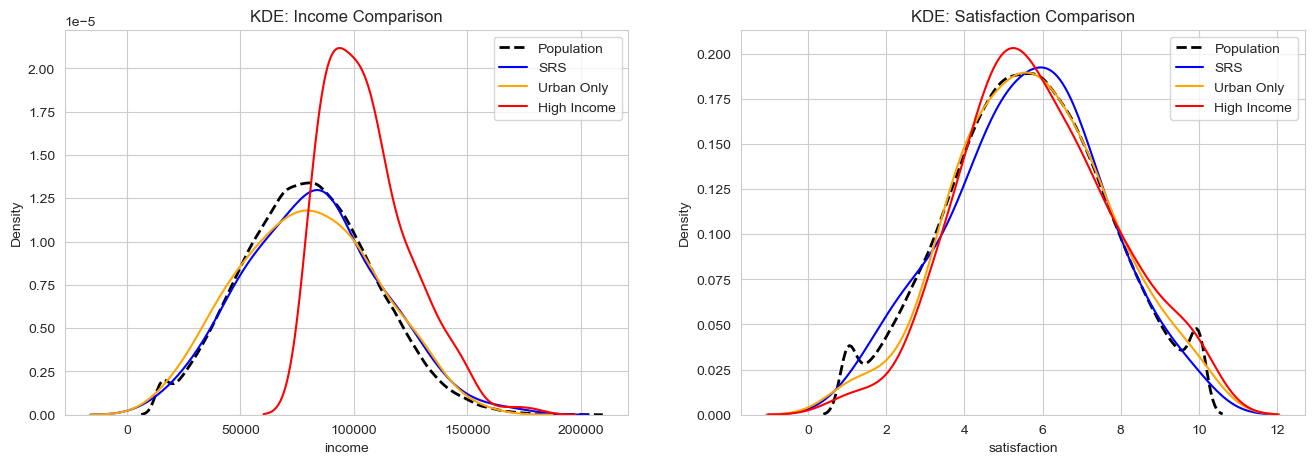

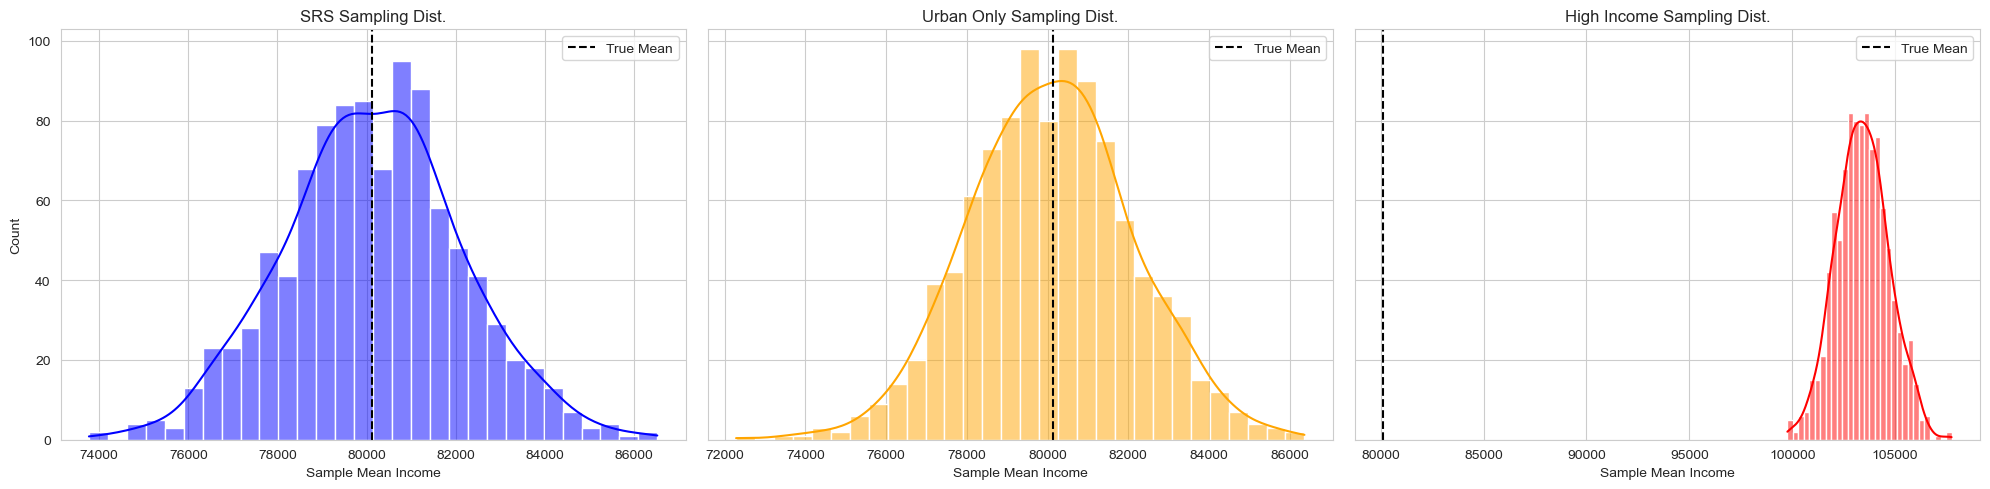

In [4]:
# 1. True Population Median for the High-Income Filter
pop_median_income = pop_df['income'].median()

# 2. Draw Samples (n=200)
sample_srs = pop_df.sample(200, random_state=42)
sample_urban = pop_df[pop_df['region'] == 'Urban'].sample(200, random_state=42)
sample_high_inc = pop_df[pop_df['income'] > pop_median_income].sample(200, random_state=42)

# 3. Comparison Table
metrics = ['age', 'income', 'satisfaction']
results = {
    'Metric': ['Mean Age', 'Mean Income', 'Mean Satisfaction'],
    'True Population': [pop_df[m].mean() for m in metrics],
    'SRS (n=200)': [sample_srs[m].mean() for m in metrics],
    'Urban Only (n=200)': [sample_urban[m].mean() for m in metrics],
    'High Income (n=200)': [sample_high_inc[m].mean() for m in metrics]
}

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

# 4. KDE Plots for Income and Satisfaction
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for col, ax in zip(['income', 'satisfaction'], axes):
    sns.kdeplot(pop_df[col], label='Population', ax=ax, color='black', lw=2, linestyle='--')
    sns.kdeplot(sample_srs[col], label='SRS', ax=ax, color='blue')
    sns.kdeplot(sample_urban[col], label='Urban Only', ax=ax, color='orange')
    sns.kdeplot(sample_high_inc[col], label='High Income', ax=ax, color='red')
    ax.set_title(f'KDE: {col.capitalize()} Comparison')
    ax.legend()

plt.show()


n_iterations = 1000
n_size = 200

means_srs = []
means_urban = []
means_high_inc = []

for _ in range(n_iterations):
    means_srs.append(pop_df['income'].sample(n_size).mean())
    means_urban.append(pop_df[pop_df['region'] == 'Urban']['income'].sample(n_size).mean())
    means_high_inc.append(pop_df[pop_df['income'] > pop_median_income]['income'].sample(n_size).mean())

# Plotting Sampling Distributions
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
titles = ['SRS Sampling Dist.', 'Urban Only Sampling Dist.', 'High Income Sampling Dist.']
data_sources = [means_srs, means_urban, means_high_inc]
colors = ['blue', 'orange', 'red']

true_mean_inc = pop_df['income'].mean()

for ax, data, title, color in zip(axes, data_sources, titles, colors):
    sns.histplot(data, bins=30, ax=ax, color=color, kde=True)
    ax.axvline(true_mean_inc, color='black', linestyle='--', label='True Mean')
    ax.set_title(title)
    ax.set_xlabel('Sample Mean Income')
    ax.legend()

plt.tight_layout()
plt.show()

#### Which sampling strategies produce biased estimates? 
Urban Only: This produces a minimally biased or unbiased estimate for income/age in this specific synthetic setup because region was assigned randomly ($60/25/15$) and was not mathematically tied to income or age. If, in the real world, Urban areas had higher salaries, this would be heavily biased.

#### How can you tell from the sampling distributions?
High-Income Filter: This produces a heavily biased estimate. By truncating the bottom half of the distribution, the sample mean is mathematically guaranteed to be significantly higher than the population mean.